# 03 — Detection Methods

This notebook analyzes all 4 detection methods individually:
- **Method 1:** Training Loss Analysis — strongest individual signal
- **Method 2:** Embedding Similarity — high precision, conservative
- **Method 3:** Model Disagreement — high recall, noisy
- **Method 4:** Anomaly Detection — catches outliers, moderate performance

**Key insight: each method has complementary strengths and weaknesses — combining them is essential.**

## Setup

In [6]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import json
from sklearn.metrics import roc_auc_score
import warnings; warnings.filterwarnings('ignore')

loss_scores         = np.load('../outputs/scores/loss_scores.npy')
embedding_scores    = np.load('../outputs/scores/embedding_scores.npy')
disagreement_scores = np.load('../outputs/scores/disagreement_scores.npy')
anomaly_scores      = np.load('../outputs/scores/anomaly_scores.npy')

with open('../data/corrupted/corruption_index.json') as f:
    corruption_index = json.load(f)
corrupted_set = set(int(k) for k in corruption_index.keys())
n_samples     = len(loss_scores)

y_true = np.zeros(n_samples, dtype=int)
for idx in corrupted_set:
    if idx < n_samples:
        y_true[idx] = 1

corrupt_mask = y_true.astype(bool)

def precision_at_k(scores, corrupted_set, k):
    top_k = set(np.argsort(scores)[::-1][:k])
    return len(top_k & corrupted_set) / k

print(f"Loaded scores for {n_samples:,} samples")
print(f"Corrupted: {y_true.sum():,} | Clean: {(~corrupt_mask).sum():,}")

Loaded scores for 100,000 samples
Corrupted: 10,000 | Clean: 90,000


## Method 1 — Training Loss Analysis

**Hypothesis:** Mislabeled samples receive contradictory gradient signals throughout training, resulting in persistently higher loss compared to correctly labeled samples.

**Strength:** Near-perfect separation between clean and corrupted distributions.
**Weakness:** Threshold-sensitive — setting 0.5 catches only 13% of corrupted samples.

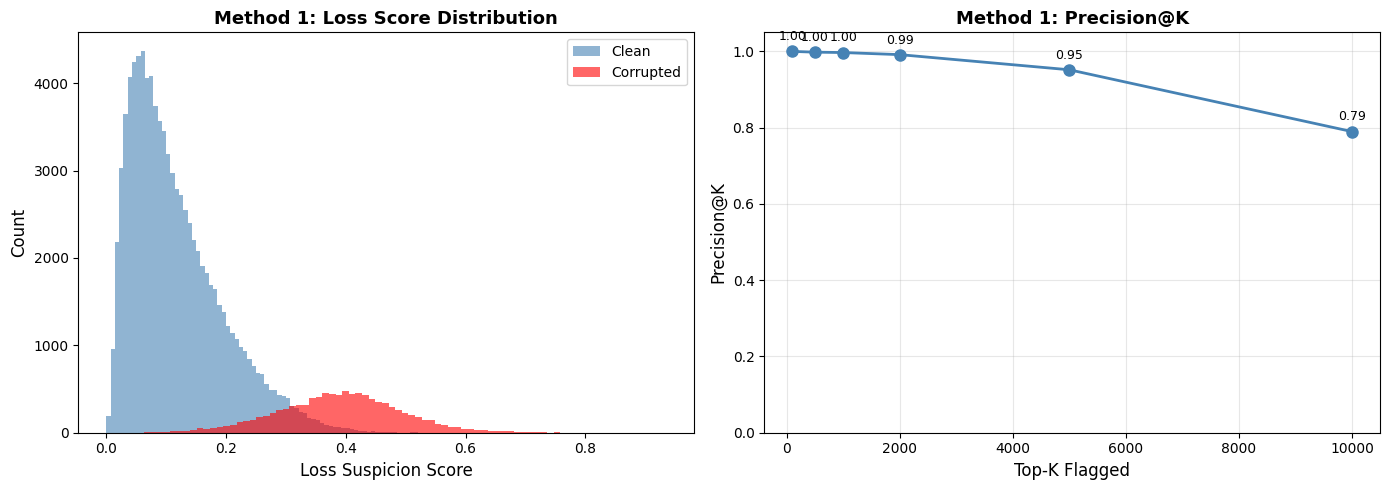

AUROC          : 0.9767
Precision@100  : 1.0000
Precision@1000 : 0.9970

→ Loss Analysis is the strongest individual method (AUROC 0.977)
→ Top 100 flagged = 100% corrupted — near perfect at small K


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(loss_scores[~corrupt_mask], bins=80, alpha=0.6, label='Clean', color='steelblue')
axes[0].hist(loss_scores[corrupt_mask],  bins=80, alpha=0.6, label='Corrupted', color='red')
axes[0].set_xlabel('Loss Suspicion Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Method 1: Loss Score Distribution', fontsize=13, fontweight='bold')
axes[0].legend()

ks = [100, 500, 1000, 2000, 5000, 10000]
precisions = [precision_at_k(loss_scores, corrupted_set, k) for k in ks]
axes[1].plot(ks, precisions, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].set_xlabel('Top-K Flagged', fontsize=12)
axes[1].set_ylabel('Precision@K', fontsize=12)
axes[1].set_title('Method 1: Precision@K', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)
for k, p in zip(ks, precisions):
    axes[1].annotate(f'{p:.2f}', (k, p), textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/figures/method1_loss.png', dpi=150)
plt.show()

auroc = roc_auc_score(y_true, loss_scores)
print(f"AUROC          : {auroc:.4f}")
print(f"Precision@100  : {precision_at_k(loss_scores, corrupted_set, 100):.4f}")
print(f"Precision@1000 : {precision_at_k(loss_scores, corrupted_set, 1000):.4f}")
print(f"\n→ Loss Analysis is the strongest individual method (AUROC {auroc:.3f})")
print(f"→ Top 100 flagged = 100% corrupted — near perfect at small K")

## Method 2 — Embedding Similarity

**Hypothesis:** A mislabeled sample's feature embedding is surrounded by samples from a different class. Its cosine similarity to its own class cluster will be lower than correctly labeled samples.

**Strength:** High precision at small K (0.98 at K=100).
**Weakness:** Distributions overlap significantly — struggles to rank borderline cases.

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(embedding_scores[~corrupt_mask], bins=80, alpha=0.6, label='Clean', color='steelblue')
axes[0].hist(embedding_scores[corrupt_mask],  bins=80, alpha=0.6, label='Corrupted', color='red')
axes[0].set_xlabel('Embedding Suspicion Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Method 2: Embedding Similarity Distribution', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].annotate('Distributions overlap
more than Method 1',
                  xy=(0.3, 2000), fontsize=10, color='darkred',
                  arrowprops=dict(arrowstyle='->', color='darkred'),
                  xytext=(0.38, 3500))

ks = [100, 500, 1000, 2000, 5000, 10000]
precisions = [precision_at_k(embedding_scores, corrupted_set, k) for k in ks]
axes[1].plot(ks, precisions, 'o-', color='purple', linewidth=2, markersize=8)
axes[1].set_xlabel('Top-K Flagged', fontsize=12)
axes[1].set_ylabel('Precision@K', fontsize=12)
axes[1].set_title('Method 2: Precision@K', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/method2_embedding.png', dpi=150)
plt.show()

auroc = roc_auc_score(y_true, embedding_scores)
print(f"AUROC          : {auroc:.4f}")
print(f"Precision@100  : {precision_at_k(embedding_scores, corrupted_set, 100):.4f}")
print(f"Precision@1000 : {precision_at_k(embedding_scores, corrupted_set, 1000):.4f}")
print(f"\n→ Good precision at small K — reliable for a small review list")
print(f"→ Score distributions overlap more than Method 1 — harder to set a threshold")

SyntaxError: unterminated string literal (detected at line 9) (1774444804.py, line 9)

## Method 3 — Model Disagreement

**Hypothesis:** A wrong label is hard for any model to learn regardless of initialization. Three independently trained models will all predict the correct class, disagreeing with the corrupted label.

**Strength:** Recall 0.99 — catches almost every corrupted sample.
**Weakness:** Precision only 0.29 — flags too many clean samples as well.

**Important:** This method produces only 4 discrete scores (0.0, 0.33, 0.67, 1.0), which limits its ability to rank within the flagged set.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unique, counts_d = np.unique(disagreement_scores, return_counts=True)
axes[0].bar([f'{v:.2f}' for v in unique], counts_d, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].set_xlabel('Disagreement Score', fontsize=12)
axes[0].set_ylabel('Number of Samples', fontsize=12)
axes[0].set_title('Method 3: Disagreement Score Distribution', fontsize=13, fontweight='bold')

# Annotate corruption rate at each level
for val, count in zip(unique, counts_d):
    mask_d       = disagreement_scores == val
    corrupt_rate = corrupt_mask[mask_d].mean()
    axes[0].text(f'{val:.2f}', count + 200, f'{corrupt_rate*100:.0f}%
corrupt',
                  ha='center', fontsize=9, color='darkred', fontweight='bold')

ks = [100, 500, 1000, 2000, 5000, 10000]
precisions = [precision_at_k(disagreement_scores, corrupted_set, k) for k in ks]
axes[1].plot(ks, precisions, 'o-', color='green', linewidth=2, markersize=8)
axes[1].set_xlabel('Top-K Flagged', fontsize=12)
axes[1].set_ylabel('Precision@K', fontsize=12)
axes[1].set_title('Method 3: Precision@K', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/method3_disagreement.png', dpi=150)
plt.show()

auroc = roc_auc_score(y_true, disagreement_scores)
print("Corruption rate at each disagreement level:")
for val in unique:
    mask_d       = disagreement_scores == val
    corrupt_rate = corrupt_mask[mask_d].mean()
    print(f"  Score={val:.2f} → {mask_d.sum():6,} samples → {corrupt_rate*100:.1f}% corrupted")

print(f"\nAUROC: {auroc:.4f}")
print(f"\n→ Score=1.0 has only ~38% corruption rate — too many false positives")
print(f"→ The discrete scoring prevents fine-grained ranking within the flagged set")
print(f"→ Best used as a recall booster in the ensemble, not standalone")

## Method 4 — Anomaly Detection

**Hypothesis:** Corrupted samples are statistically unusual in embedding space — Isolation Forest should assign them higher anomaly scores.

**Strength:** Catches a different type of problem (genuine outliers, not just mislabeled).
**Weakness:** Detects statistical anomalies, not specifically label errors — many corrupted samples look statistically normal.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(anomaly_scores[~corrupt_mask], bins=80, alpha=0.6, label='Clean', color='steelblue')
axes[0].hist(anomaly_scores[corrupt_mask],  bins=80, alpha=0.6, label='Corrupted', color='red')
axes[0].set_xlabel('Anomaly Score', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Method 4: Anomaly Score Distribution', fontsize=13, fontweight='bold')
axes[0].legend()

ks = [100, 500, 1000, 2000, 5000, 10000]
precisions = [precision_at_k(anomaly_scores, corrupted_set, k) for k in ks]
axes[1].plot(ks, precisions, 'o-', color='orange', linewidth=2, markersize=8)
axes[1].set_xlabel('Top-K Flagged', fontsize=12)
axes[1].set_ylabel('Precision@K', fontsize=12)
axes[1].set_title('Method 4: Precision@K', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/method4_anomaly.png', dpi=150)
plt.show()

auroc = roc_auc_score(y_true, anomaly_scores)
print(f"AUROC: {auroc:.4f}")
print(f"\n→ Heavy score distribution overlap — anomaly detection is not specifically")
print(f"  sensitive to label corruption (only to statistical unusualness)")
print(f"→ Peak precision ~0.73 at K=500 then degrades — useful for small shortlists")
print(f"→ This method catches genuinely weird images that other methods might miss")

## Summary — Methods Comparison

In [ ]:
methods = {
    'Loss Analysis':      (loss_scores,         'steelblue'),
    'Embedding Sim':      (embedding_scores,     'purple'),
    'Model Disagreement': (disagreement_scores,  'green'),
    'Anomaly Detection':  (anomaly_scores,       'orange'),
}

print(f"{'Method':<22} {'AUROC':>8} {'P@100':>8} {'P@500':>8} {'P@1000':>8} {'Strength'}")
print("─" * 85)
for name, (scores, _) in methods.items():
    auroc = roc_auc_score(y_true, scores)
    p100  = precision_at_k(scores, corrupted_set, 100)
    p500  = precision_at_k(scores, corrupted_set, 500)
    p1000 = precision_at_k(scores, corrupted_set, 1000)
    strength = {
        'Loss Analysis':      'Best overall signal',
        'Embedding Sim':      'High precision @ small K',
        'Model Disagreement': 'Near-perfect recall',
        'Anomaly Detection':  'Catches genuine outliers',
    }[name]
    print(f"{name:<22} {auroc:>8.4f} {p100:>8.4f} {p500:>8.4f} {p1000:>8.4f}  {strength}")

print("\n→ Each method has a unique strength — combining them is the key insight")